In [6]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="@rthuR5134",
    database="northwind"
)

print("Conexão bem sucedida!" if conn.is_connected() else "Falhou!")

Conexão bem sucedida!


In [17]:
query = "SELECT DATE_FORMAT(order_date, '%Y-%m') , SUM(d.quantity * d.unit_price) AS total_revenue FROM orders o LEFT JOIN order_details d ON o.id = d.order_id GROUP BY DATE_FORMAT(order_date, '%Y-%m') ORDER BY DATE_FORMAT(order_date, '%Y-%m');"
df_receita = pd.read_sql(query, conn)
print(df_receita)

  DATE_FORMAT(order_date, '%Y-%m')  total_revenue
0                          2006-01        3836.00
1                          2006-02        2241.50
2                          2006-03       32609.25
3                          2006-04       19355.25
4                          2006-05        1788.50
5                          2006-06        8306.50


/var/folders/lm/qlcqmmrj799_1knxlqrtpvwh0000gn/T/ipykernel_97690/1933129825.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_receita = pd.read_sql(query, conn)


/var/folders/lm/qlcqmmrj799_1knxlqrtpvwh0000gn/T/ipykernel_97690/521387065.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


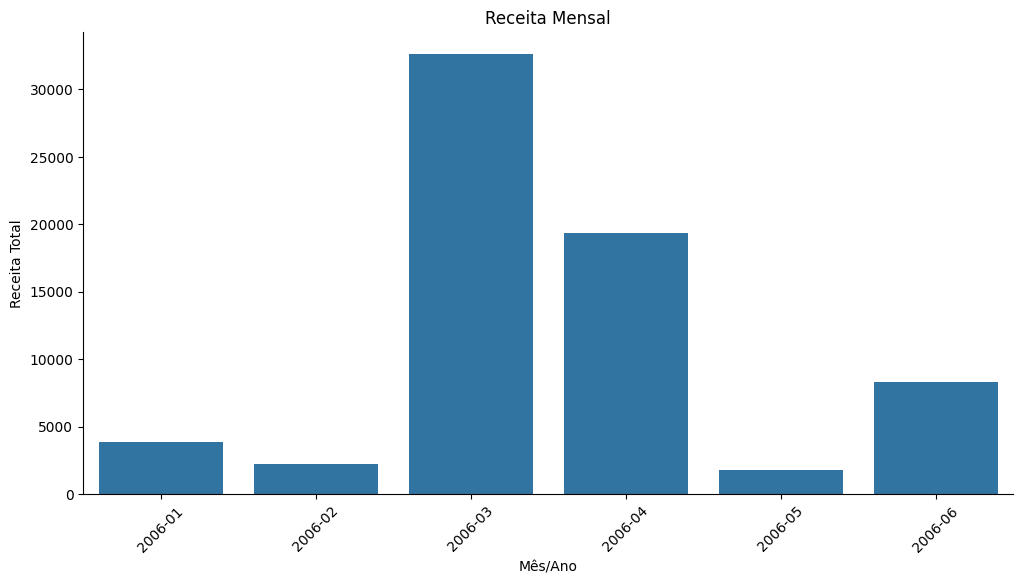

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
df_receita = df_receita.rename(columns={"DATE_FORMAT(order_date, '%Y-%m')": 'year_month'})

ax = sns.barplot(x='year_month', y='total_revenue', data=df_receita)
ax.figure.set_size_inches(12, 6)
ax.set_title('Receita Mensal')
ax.set_xlabel('Mês/Ano')
ax.set_ylabel('Receita Total')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.savefig('charts/receita_mensal.png', dpi=150, bbox_inches='tight')
sns.despine()

/var/folders/lm/qlcqmmrj799_1knxlqrtpvwh0000gn/T/ipykernel_97690/3742294144.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_produtos = pd.read_sql(query,conn)


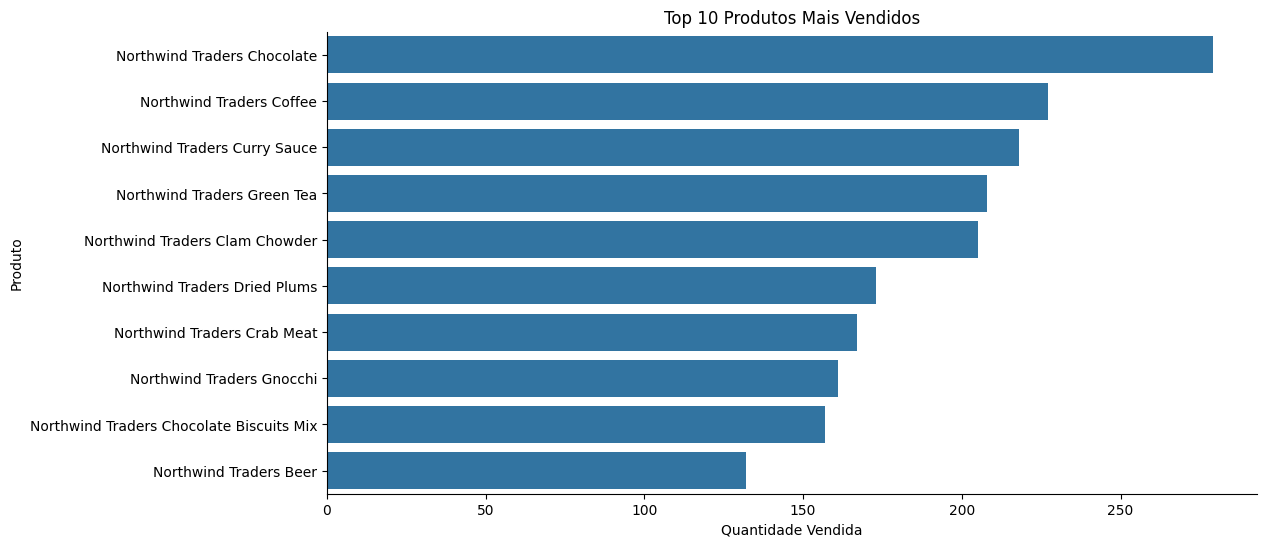

In [29]:
query = "SELECT p.product_name, SUM(o.order_id) AS orders_quantity FROM products p INNER JOIN order_details o ON p.id = o.product_id GROUP BY p.product_name ORDER BY SUM(o.order_id) DESC LIMIT 10;"
df_produtos = pd.read_sql(query,conn)

ax = sns.barplot(x='orders_quantity' , y='product_name', data=df_produtos)
ax.figure.set_size_inches(12, 6)
ax.set_title('Top 10 Produtos Mais Vendidos')
ax.set_xlabel('Quantidade Vendida')
ax.set_ylabel('Produto')
plt.savefig('charts/top_produtos.png', dpi=150, bbox_inches='tight')
sns.despine()


/var/folders/lm/qlcqmmrj799_1knxlqrtpvwh0000gn/T/ipykernel_97690/2712234316.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_margem = pd.read_sql(query,conn)


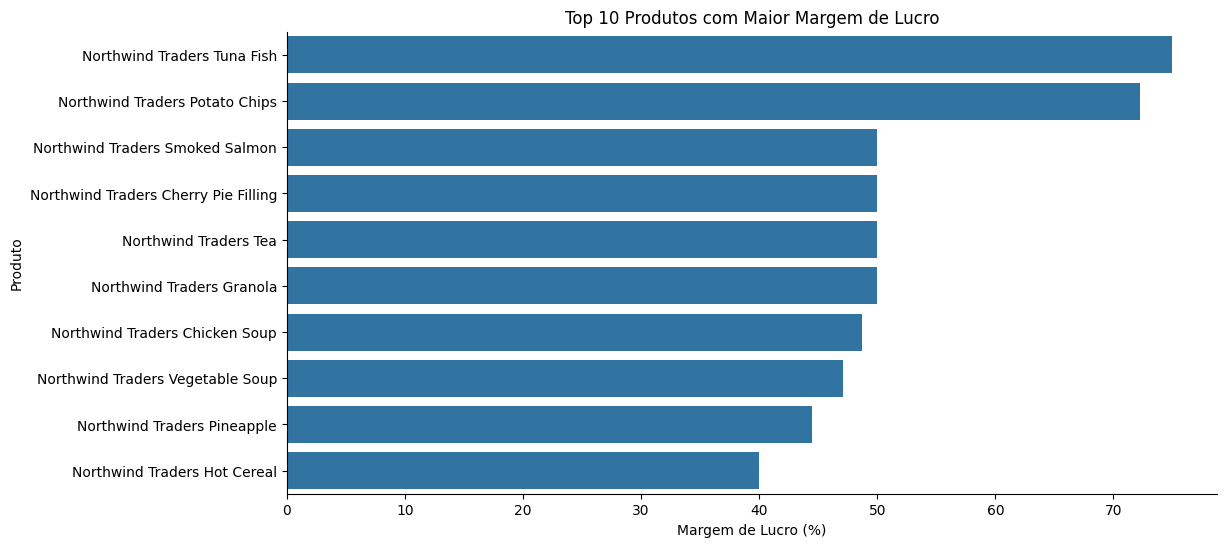

In [30]:
query = "select product_name, (((list_price - standard_cost) / list_price) * 100 ) as margin_revenue from products order by margin_revenue desc"
df_margem = pd.read_sql(query,conn)

ax = sns.barplot(x='margin_revenue' , y='product_name', data=df_margem.head(10))
ax.figure.set_size_inches(12, 6)
ax.set_title('Top 10 Produtos com Maior Margem de Lucro')
ax.set_xlabel('Margem de Lucro (%)')
ax.set_ylabel('Produto')
plt.savefig('charts/margem_lucro.png', dpi=150, bbox_inches='tight')
sns.despine()

In [23]:
with pd.ExcelWriter('northwind_relatorio.xlsx', engine = 'openpyxl') as writer:
    df_receita.to_excel(writer,sheet_name = 'Receita Mensal', index=False)
    df_produtos.to_excel(writer,sheet_name = 'Top Produtos', index=False)
    df_margem.to_excel(writer,sheet_name = 'Margem de Lucro', index=False)
    

NameError: name 'plt' is not defined